**<h1>Building model using Componentwise Gradient Boosting</h1>**

**Import the Dependenicies**

In [1]:
!pip install scikit-survival

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import calendar

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, ComponentwiseGradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold

In [3]:
from sksurv.util import Surv

In [4]:
# Change event feature to boolean dtype
# Target features to an array
# [event, time_to_hit_hours]
  # [18.892512, False] -> [False, 18.89]

</br>
</br>
</br>

**Load the Data from Excel into Dataframes**

In [5]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDS Global Datathon 2026/Train & Test Data/train.csv', index_col = "event_id")
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDS Global Datathon 2026/Train & Test Data/test.csv', index_col = "event_id")
sample_submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDS Global Datathon 2026/Train & Test Data/sample_submission.csv')
metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDS Global Datathon 2026/Train & Test Data/metaData.csv')

In [6]:
metadata.head()

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95 entries, 10662602 to 99649465
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           95 non-null     int64  
 1   dt_first_last_0_5h            95 non-null     float64
 2   low_temporal_resolution_0_5h  95 non-null     int64  
 3   area_first_ha                 95 non-null     float64
 4   area_growth_abs_0_5h          95 non-null     float64
 5   area_growth_rel_0_5h          95 non-null     float64
 6   area_growth_rate_ha_per_h     95 non-null     float64
 7   log1p_area_first              95 non-null     float64
 8   log1p_growth                  95 non-null     float64
 9   log_area_ratio_0_5h           95 non-null     float64
 10  relative_growth_0_5h          95 non-null     float64
 11  radial_growth_m               95 non-null     float64
 12  radial_growth_rate_m_per_h    95 non-null     float64
 13 

In [8]:
df_test.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
event_id,,,,,,,,,,,,,,,,,,,,,
10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,0.186363,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


In [9]:
# Sample submission data
sample_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


</br>
</br>
</br>

**Exploratory Data Analysis (EDA)**

In [10]:
df_train.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
event_id,,,,,,,,,,,,,,,,,,,,,
10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [11]:
print("Shape: ", df_train.shape)
print(df_train.info())

Shape:  (221, 36)
<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 10892457 to 99339733
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-n

<br/>
<br/>

<h2>
Feature Engineering
</h2>

In [12]:
df_train["dist_min_ci_0_5h"].head()

,dist_min_ci_0_5h
event_id,
10892457,6166.121596
11757157,2930.925956
11945086,3272.375090
12044083,64119.871377
12052347,18005.432261


In [13]:
print(f"Minimum distance: {df_train["dist_min_ci_0_5h"].min()}")
print(f"Maximum distance: {df_train["dist_min_ci_0_5h"].max()}")

Minimum distance: 306.95455122724024
Maximum distance: 757700.487102109


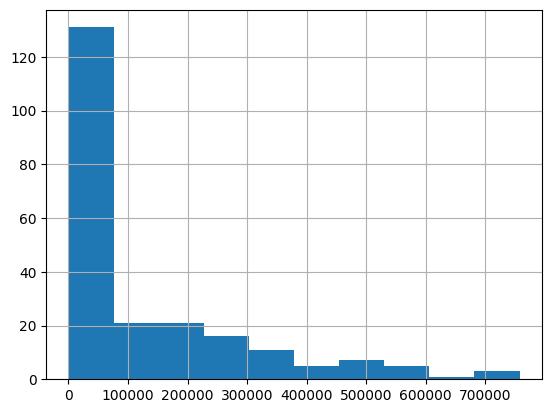

In [14]:
# Histogram showing minimum distance to nearest evac zone
df_train["dist_min_ci_0_5h"].hist();

In [15]:
df_train["dist_min_ci_0_5h"].describe()

,dist_min_ci_0_5h
count,221.000000
mean,124399.237725
std,171302.559054
min,306.954551
25%,2965.217571
50%,31758.581144
75%,200228.863652
max,757700.487102


In [16]:
df_train["radial_growth_rate_m_per_h"].value_counts()

,count
radial_growth_rate_m_per_h,
0.000000,196
2.111790,1
19.969101,1
15.935095,1
26.474767,1
0.401498,1
15.108421,1
0.004498,1
0.228357,1


<br/>
<br/>

In [17]:
# Time that had the most numbers of event starting-time observations
event_start_hour = df_train["event_start_hour"].value_counts()
event_start_hour


,count
event_start_hour,
21,33
22,30
20,23
18,20
23,18
0,16
19,13
16,11
2,9


In [18]:
# High values for both features signifies an aggressive mobile fire
df_train[["area_growth_rate_ha_per_h", "centroid_speed_m_per_h"]].sort_values(by = "centroid_speed_m_per_h",ascending = False ).head()

,area_growth_rate_ha_per_h,centroid_speed_m_per_h
event_id,,
70401139,182.820074,595.058697
60132804,520.443033,424.426546
59863246,124.525831,258.006167
80550714,88.573191,235.166604
84940844,31.054997,216.184540


In [19]:
# Fire directly approaching evac zone quickly (When both features are high)
df_train[["closing_speed_m_per_h", "alignment_abs"]].sort_values(by = "closing_speed_m_per_h", ascending = False).head()

,closing_speed_m_per_h,alignment_abs
event_id,,
60132804,354.120897,0.902628
49907151,134.637726,0.994594
65120642,93.922570,0.796469
69453871,25.336113,0.326959
54555851,18.506421,0.231012


In [20]:
# What percentage of fires hit?
event = (df_train["event"]).value_counts()
event

,count
event,
0,152
1,69


In [21]:
# Unique area growth rate where fire hit evacuation zones(event = 1) within 72h
print(df_train["area_growth_rate_ha_per_h"][df_train["event"] == 1].unique())

[ 0.00000000e+00  4.16444985e+00  8.19766902e+00  1.07844859e+01
  3.44630084e+00  5.54749656e-04  3.18730805e+00  3.01816268e+00
  6.50236167e+01  2.90669901e+01  5.20443033e+02  1.32352921e+01
  1.68409928e+02  1.82820074e+02  7.03124540e+00 -5.29284592e-06
  8.85731908e+01  3.10549968e+01  6.62920158e-04]


In [22]:
df_train["event_start_hour"].describe()

,event_start_hour
count,221.000000
mean,15.429864
std,7.921250
min,0.000000
25%,9.000000
50%,19.000000
75%,21.000000
max,23.000000


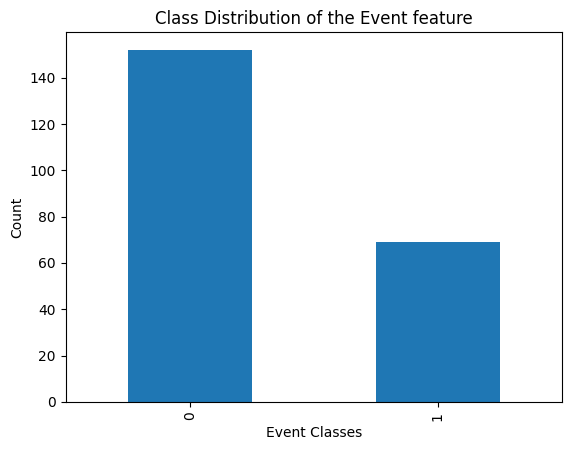

In [23]:
# Bar chart of the event classes
event.plot(
    kind = "bar",
    )

plt.xlabel("Event Classes")
plt.ylabel("Count")
plt.title("Class Distribution of the Event feature");

In [24]:
# # Months that had the highest distribution of events
# month_order = list(calendar.month_name[1:])
# monthEvent = pd.crosstab(
#     df_train["event_start_month"],
#     df_train["event"]
# )

# # Reindex by correct month order
# monthEvent = monthEvent.reindex([m for m in month_order if m in monthEvent.index])
# monthEvent

In [25]:
# # Bar chart showing the month distribution of the event classes
# monthEvent.plot(
#     kind = "bar"
# )

# plt.xlabel("Months")
# plt.ylabel("Frequency")
# plt.title("Frequency of Events against Months ");

In [26]:
df_train["time_to_hit_hours"].unique()

array([1.88925118e+01, 2.20481080e+01, 8.88895483e-01, 6.09530215e+01,
       4.49902745e+01, 4.40263836e+01, 1.48453918e+01, 6.67679270e+01,
       3.99126301e+01, 5.46381094e+01, 6.66439690e+01, 1.59246879e+01,
       1.09074590e+01, 1.82804653e+01, 5.54643427e+01, 6.45674854e+01,
       2.38438434e+01, 3.53484561e+00, 5.81815958e+00, 6.64281031e+01,
       3.73947605e+01, 2.41724995e+01, 6.64422306e+01, 6.12658726e+01,
       5.23763411e-01, 5.76438066e+01, 1.39796932e+00, 2.56443962e+00,
       6.28166641e+01, 4.89252955e+01, 5.84172862e-01, 5.45866301e+00,
       3.76167108e+01, 6.62710855e+01, 6.37164247e+01, 1.88046103e+01,
       3.21134343e+00, 1.47281399e+01, 6.64039128e+01, 6.56896544e+01,
       6.64489979e+01, 1.12543443e+01, 1.47523102e+00, 1.99296374e+00,
       4.44304912e+00, 1.28211783e+01, 5.97708404e+01, 1.57785977e+00,
       6.03139902e+01, 6.14817681e+01, 4.79970215e+01, 6.50849293e+01,
       6.62960358e+01, 1.36567870e+01, 2.10724622e+01, 6.61317720e+01,
      

From above observations, most fires that hit (event = 1), they started at 7pm; median(50%) = 19. <br> Also, event = 1 has some outliers, represented by the circles before the minimum mark.

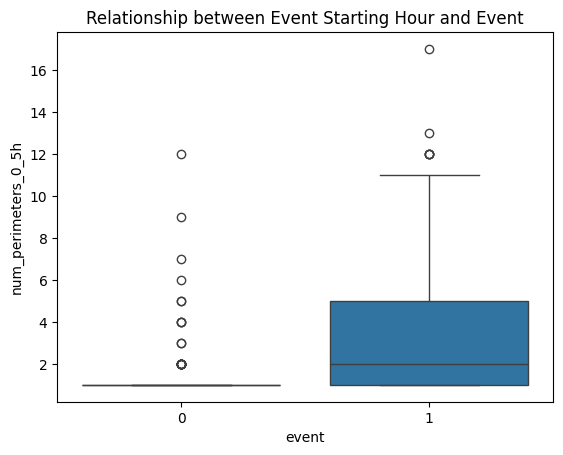

In [27]:
# At what time time did most fires hit?
sns.boxplot(
    x = df_train["event"],
    y = df_train["num_perimeters_0_5h"]
)
plt.title("Relationship between Event Starting Hour and Event");

In [28]:
event_class = df_train["event"].value_counts()
event_class

,count
event,
0,152
1,69


In [29]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 10892457 to 99339733
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-null    float64
 13

In [30]:
# Correlation between all features except the target features
corr = df_train.select_dtypes(exclude = ["object"]).drop(columns = ["time_to_hit_hours", "event"]).corr()
print("Correlation matrix: ")
corr.head()

Correlation matrix: 


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
num_perimeters_0_5h,1.000000,0.667314,-0.673017,-0.117057,0.474259,0.502281,0.522499,-0.109423,0.784831,0.724456,...,0.315076,-0.267586,0.436162,0.077316,0.590605,0.172545,0.074457,0.156423,0.010015,-0.043686
dt_first_last_0_5h,0.667314,1.000000,-0.923622,-0.172628,0.281809,0.195953,0.289782,-0.198299,0.514515,0.345499,...,0.180727,-0.203947,0.497341,0.035579,0.823127,0.062732,0.083141,0.202332,-0.005273,0.014960
low_temporal_resolution_0_5h,-0.673017,-0.923622,1.000000,0.199176,-0.230652,-0.225602,-0.250207,0.281554,-0.476915,-0.357717,...,-0.131277,0.143319,-0.439878,0.022043,-0.861182,-0.070261,-0.019370,-0.184362,-0.007760,-0.026156
area_first_ha,-0.117057,-0.172628,0.199176,1.000000,0.037155,-0.044999,0.029056,0.621912,-0.046068,-0.058269,...,0.043750,-0.033100,-0.058690,0.019055,-0.171052,-0.049385,0.043538,-0.184683,0.064508,-0.019375
area_growth_abs_0_5h,0.474259,0.281809,-0.230652,0.037155,1.000000,0.325878,0.991339,0.103716,0.669160,0.486166,...,0.855030,-0.737906,0.344149,0.177724,0.220966,-0.122571,0.418101,0.067744,-0.041576,-0.078409


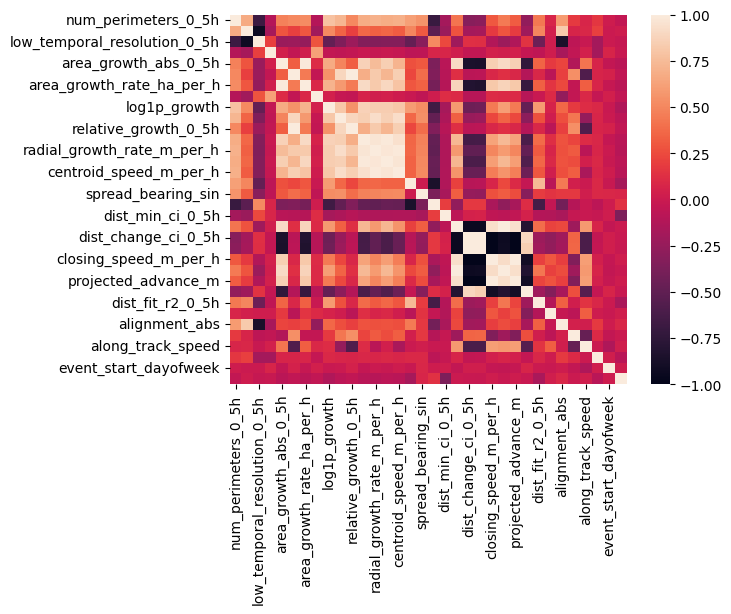

In [31]:
sns.heatmap(corr);
# The heatmap shows signs of multicollinearity

In [32]:
# Filter columns with high correlation while omitting self targets(corr = 1.0)
high_corr = corr[(corr > 0.80) & (corr < 1.00)]
filtered_df_train = high_corr.stack().reset_index()
filtered_df_train.columns = ['feature_1', 'feature_2', 'correlation']
filtered_df_train.sort_values(by = "correlation", ascending=False)

,feature_1,feature_2,correlation
85,projected_advance_m,closing_speed_m_per_h,0.998166
76,closing_speed_m_per_h,projected_advance_m,0.998166
66,dist_std_ci_0_5h,closing_speed_abs_m_per_h,0.996875
79,closing_speed_abs_m_per_h,dist_std_ci_0_5h,0.996875
70,dist_slope_ci_0_5h,dist_change_ci_0_5h,0.993057
...,...,...,...
16,area_growth_rate_ha_per_h,closing_speed_m_per_h,0.815404
23,log1p_growth,centroid_speed_m_per_h,0.812041
57,centroid_speed_m_per_h,log1p_growth,0.812041
25,log_area_ratio_0_5h,log1p_growth,0.810486


In [33]:
# Identify the columns to drop
cols = []

# Remove redundant transforms
cols.extend([
    "area_growth_rel_0_5h",
    "relative_growth_0_5h",
    "log1p_growth"
      ]
    )

# Remove nearly duplicate in terms of area growth
cols.append("area_growth_abs_0_5h")

# Remove nearly similar in terms of speed
cols.extend(
    [
        "closing_speed_m_per_h",
        "closing_speed_abs_m_per_h",
        "dist_std_ci_0_5h"
    ]
)

# Radial growth is better than centroid movement
cols.extend(
    [
        "centroid_displacement_m",
        "centroid_speed_m_per_h"
    ]
)

# Remove acceleration redundancy
cols.extend(
    [
        "dist_change_ci_0_5h",
        "dist_slope_ci_0_5h"
    ]
)

print(len(cols))


11


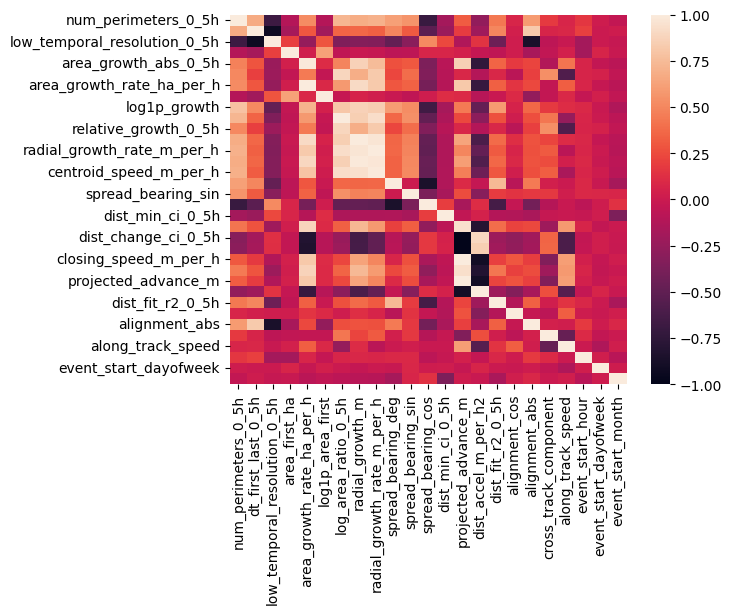

In [34]:
sns.heatmap(corr.drop(columns=cols));

In [35]:
df_train["radial_growth_m"].corr(df_train["time_to_hit_hours"])

np.float64(-0.21737935832973093)

In [36]:
df_train["projected_advance_m"].corr(df_train["time_to_hit_hours"])

np.float64(-0.1317727099024273)

In [37]:
# Recast the event column as boolean type
df_train["event"] = df_train["event"].astype(bool)

In [38]:
df_train["event"].head()

,event
event_id,
10892457,False
11757157,True
11945086,True
12044083,False
12052347,False


In [39]:
# df_test = df_test.drop(columns = cols)

<Axes: ylabel='Frequency'>

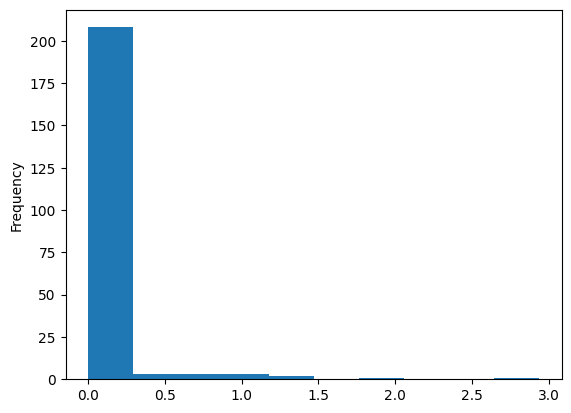

In [40]:
np.log1p(df_train["area_growth_rel_0_5h"]).plot(
    kind = "hist"
)

<Axes: ylabel='Frequency'>

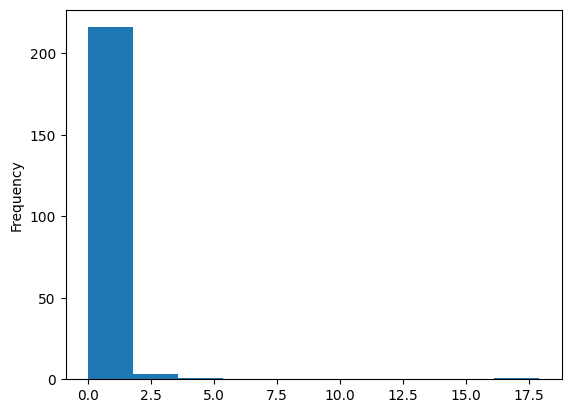

In [41]:
df_train["area_growth_rel_0_5h"].plot(
    kind = "hist"
)

<Axes: ylabel='Frequency'>

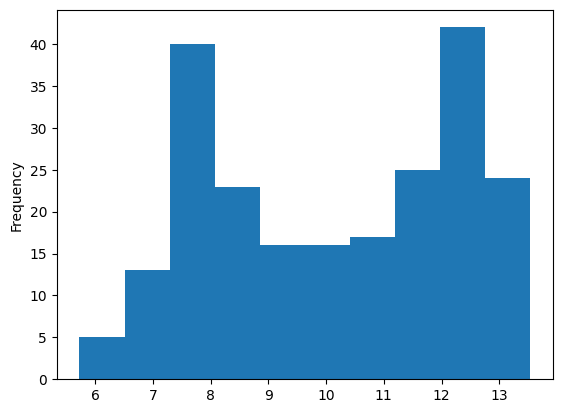

In [42]:
np.log1p(df_train["dist_min_ci_0_5h"]).plot(
    kind = "hist"
)

<Axes: ylabel='Frequency'>

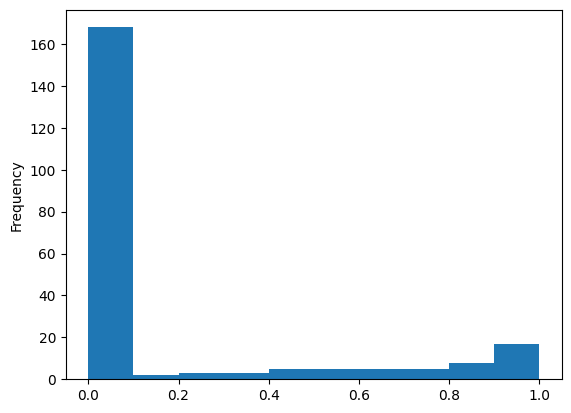

In [43]:
df_train["alignment_abs"].plot(
    kind = "hist"
)

In [44]:
(df_train["alignment_abs"] > 0.1).astype(int).head()

,alignment_abs
event_id,
10892457,0
11757157,1
11945086,1
12044083,0
12052347,1


In [45]:
(df_train["area_growth_rel_0_5h"] > 1.9).astype(int).value_counts()

,count
area_growth_rel_0_5h,
0,216
1,5


<Axes: ylabel='Frequency'>

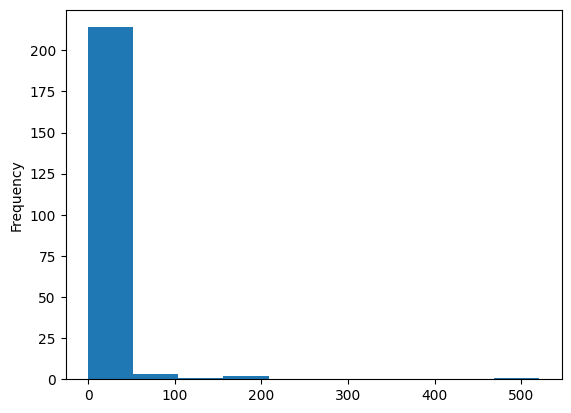

In [46]:
df_train["area_growth_rate_ha_per_h"].plot(
    kind = "hist"
)

In [47]:
df_train[["closing_speed_m_per_h", "alignment_abs"]].sort_values(
    by = ["closing_speed_m_per_h", "alignment_abs"],
    ascending = False
).head(10)

,closing_speed_m_per_h,alignment_abs
event_id,,
60132804,354.120897,0.902628
49907151,134.637726,0.994594
65120642,93.922570,0.796469
69453871,25.336113,0.326959
54555851,18.506421,0.231012
51688491,1.371360,0.030362
25909534,0.023869,0.937067
85752079,0.001466,0.610489
61186593,0.000000,0.999995


In [48]:
(df_train["dist_min_ci_0_5h"] <= 5000 ).astype(int).value_counts()

,count
dist_min_ci_0_5h,
0,152
1,69


<Axes: ylabel='Frequency'>

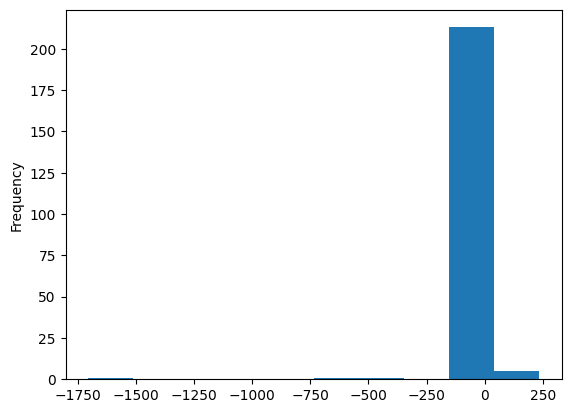

In [49]:
df_train["dist_change_ci_0_5h"].plot(
    kind = "hist"
)

In [50]:
(df_train["dist_change_ci_0_5h"]< -250).astype(int).value_counts()

,count
dist_change_ci_0_5h,
0,218
1,3


<Axes: ylabel='Frequency'>

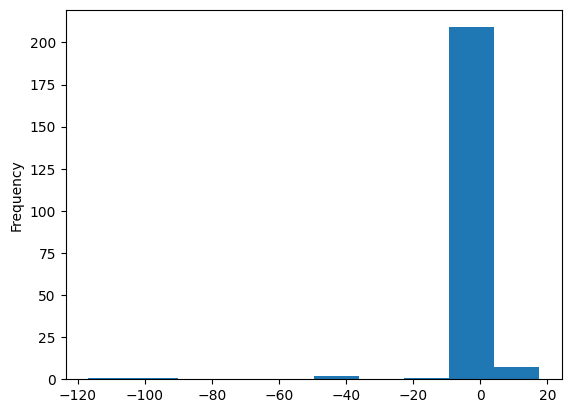

In [51]:
df_train["dist_accel_m_per_h2"].plot(
    kind = "hist"
)

In [52]:
((df_train["dist_change_ci_0_5h"] < -250) & (df_train["dist_accel_m_per_h2"] < -20)).astype(int).value_counts()

,count
0,218
1,3


In [53]:
pd.DataFrame([(np.sin(2 * np.pi * df_train["event_start_hour"] / 24)), (np.cos(2 * np.pi * df_train["event_start_hour"] / 24))]).head()

event_id,10892457,11757157,11945086,12044083,12052347,12773599,13122360,13745272,15247236,15743535,...,94424495,94488511,95839532,96270286,96372213,97075632,97362560,97805715,99071478,99339733
event_start_hour,-0.965926,0.866025,-0.500000,-0.866025,-0.707107,0.0,-0.707107,-0.866025,-1.000000e+00,-0.965926,...,0.0,-0.866025,-0.258819,-0.866025,-0.707107,-0.965926,-1.000000e+00,-1.000000e+00,-0.707107,-0.707107
event_start_hour,0.258819,0.500000,0.866025,0.500000,0.707107,1.0,0.707107,-0.500000,-1.836970e-16,-0.258819,...,1.0,-0.500000,0.965926,0.500000,0.707107,-0.258819,-1.836970e-16,-1.836970e-16,-0.707107,0.707107


In [54]:
search = df_train[["event_start_hour", "event"]].sort_values(by = "event_start_hour", ascending = False)
search[search["event"] == True].value_counts()

,,count
event_start_hour,event,
22,True,15
18,True,7
19,True,7
21,True,7
20,True,5
0,True,5
17,True,4
16,True,4
15,True,3


In [55]:
def wrangle(data):

  data = data.copy()

  threshold = 5000

  # Fix skewness
  data["log_dist_min_ci"] = np.log1p(data["dist_min_ci_0_5h"])

  # Area growth flagging
  data["area_growth"] = (data["area_growth_rel_0_5h"] > 2.0).astype(int)

  # Alignment flagging
  data["fire_aimed_at_evac_zone"] = (data["alignment_abs"] > 0.1).astype(int)

  # fire_is_spreading from radial_growth_rate_m_per_h
  data["fire_is_spreading"] = (
      data["radial_growth_rate_m_per_h"] > 1
  ).astype(int)

  # log transformation of radial_growth_rate_m_per_h
  data["log_radial_growth"] = np.where(
      data["radial_growth_rate_m_per_h"] > 0,
      np.log1p(data["radial_growth_rate_m_per_h"]),
      0
  )

  # Close to evac zone
  data["close_to_zone"] = (data["dist_min_ci_0_5h"] <= threshold).astype(int)

  # Rapid closure
  data["rapid_closure"] = ((data["dist_change_ci_0_5h"] < -250) & (data["dist_accel_m_per_h2"] < -20)).astype(int)

  # Temporal Cyclical
  data["hour_sin"] = np.sin(2 * np.pi * data["event_start_hour"] / 24)
  data["hour_cos"] = np.cos(2 * np.pi * data["event_start_hour"] / 24)

  data["is_night"] = (
      (data["event_start_hour"] >= 20) |
      (data["event_start_hour"] <= 6)
  ).astype(int)
  data["growing_peak_times"] = data["event_start_hour"].between(12, 17).astype(int) # Heuristic
  data["high_peak_times"] = data["event_start_hour"].between(18, 22).astype(int) # Emperical Evidence

  if "event_start_month" in data.columns:
      data["month_sin"] = np.sin(2 * np.pi * data["event_start_month"] / 12)
      data["month_cos"]  = np.cos(2 * np.pi * data["event_start_month"] / 12)
      data["is_fire_season"] = data["event_start_month"].isin(
          [6, 7, 8, 9]
      ).astype(int)

  # Identify the columns to drop
  cols = []

  # Remove redundant transforms
  cols.extend([
      "area_growth_rel_0_5h",
      "relative_growth_0_5h",
      "log1p_growth"
        ]
      )

  # Remove nearly duplicate in terms of area growth
  cols.append("area_growth_abs_0_5h")

  # Remove nearly similar in terms of speed
  cols.extend(
      [
          "closing_speed_m_per_h",
          "closing_speed_abs_m_per_h",
          "dist_std_ci_0_5h"
      ]
  )

  # Radial growth is better than centroid movement
  cols.extend(
      [
          "centroid_displacement_m",
          "centroid_speed_m_per_h"
      ]
  )

  # Remove acceleration redundancy
  cols.extend(
      [
          "dist_change_ci_0_5h",
          "dist_slope_ci_0_5h"
      ]
  )

  data = data.drop(columns = cols)

  return data



  </br>
  </br>
  </br>

In [56]:
wrangle_transformer = FunctionTransformer(wrangle)

In [57]:
col = "area_growth_rel_0_5h"
print(df_train[col].describe())

for threshold in [0, 0.5, 1.0, 2.0, 5.0]:
    above = df_train[df_train[col] > threshold]
    below = df_train[df_train[col] <= threshold]
    if len(above) > 5:
        print(f"> {threshold:<5} n={len(above):>3} "
              f"event={above['event'].mean():.3f} | "
              f"n={len(below):>3} event={below['event'].mean():.3f}")

count    2.210000e+02
mean     1.789087e-01
std      1.302001e+00
min     -1.437844e-07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.788970e+01
Name: area_growth_rel_0_5h, dtype: float64
> 0     n= 24 event=0.708 | n=197 event=0.264
> 0.5   n= 11 event=0.727 | n=210 event=0.290
> 1.0   n=  7 event=0.857 | n=214 event=0.294


**Split Data** </br>
Needed test data in order to get the model score

In [58]:
# Identify the feature matrix (X) and the target vector (y)
# Drop the high correlated features
target = ["event", "time_to_hit_hours"]
X = df_train.drop(columns = target)
y = df_train[target]

print(f"X shape is {X.shape}")
print(f"y shape is {y.shape}")

X shape is (221, 34)
y shape is (221, 2)


In [59]:
print(X.columns)

Index(['num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h',
       'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first',
       'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
       'radial_growth_m', 'radial_growth_rate_m_per_h',
       'centroid_displacement_m', 'centroid_speed_m_per_h',
       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
       'dist_slope_ci_0_5h', 'closing_speed_m_per_h',
       'closing_speed_abs_m_per_h', 'projected_advance_m',
       'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos',
       'alignment_abs', 'cross_track_component', 'along_track_speed',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month'],
      dtype='object')


In [60]:
# Split data; 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, shuffle = True
)

print(f"X_train shape is {X_train.shape}")
print(f"X_test shape is {X_test.shape}")
print(f"y_train shape is {y_train.shape}")
print(f"y_test shape is {y_test.shape}")

X_train shape is (154, 34)
X_test shape is (67, 34)
y_train shape is (154, 2)
y_test shape is (67, 2)


In [61]:
# The model is sensitive about the format of data hence converted to compatible arrays using surv class
y_train = Surv.from_arrays(event=y_train[target[0]], time=y_train[target[1]])
y_test = Surv.from_arrays(event=y_test[target[0]], time=y_test[target[1]])

In [62]:
print(y_train[:5])

[(False, 64.61591896) (False, 66.72742123) (False, 15.15400424)
 (False, 12.24232216) ( True,  5.45866301)]


In [63]:
# n_events = sum([yi[0] for yi in y_train])
# epv = n_events / X.shape[1]
# print(f"Events : {n_events}")
# print(f"Features : {X.shape[1]}")
# print(f"EPV : {epv:.1f}")
# print(f"Verdict : {'OK' if epv >= 10 else 'Too many features for dataset size'}")

</br>
</br>
</br>

**Build Model**

In [64]:
# Instantiate the model
model = ComponentwiseGradientBoostingSurvivalAnalysis(
    random_state = 42,
    verbose = 1
)

</br>
</br>
</br>

**Cross Validation**

In [65]:
pipeline_steps = [
    ('engineer', wrangle_transformer),
    ("scaler", StandardScaler()),
    ('model', model)
]

pipeline = Pipeline(steps = pipeline_steps)

In [66]:
# Peform cross validation using GridSearchCV from Scikit learn
param_grid = {
    "model__n_estimators": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    "model__learning_rate": [0.05, 0.1, 0.2]
}

cv = RepeatedKFold(
    n_splits = 5,
    n_repeats = 10,
    random_state = 42
)

cross_val = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = cv,
    n_jobs = -1,
    verbose = 1,
    refit = True
)


In [67]:
# Fit the model
cross_val.fit(X_train, y_train)

Fitting 50 folds for each of 30 candidates, totalling 1500 fits
      Iter       Train Loss   Remaining Time 
         1         213.8277            0.38s
         2         209.6611            0.31s
         3         205.6802            0.28s
         4         201.8867            0.27s
         5         198.2808            0.26s
         6         194.8613            0.25s
         7         191.6254            0.25s
         8         188.5693            0.24s
         9         185.6880            0.24s
        10         182.9757            0.24s
        20         163.5497            0.22s
        30         153.3031            0.20s
        40         147.5422            0.19s
        50         143.4613            0.19s
        60         140.1142            0.18s
        70         137.3683            0.17s
        80         135.1107            0.16s
        90         133.2487            0.16s
       100         131.7032            0.15s
       200         124.0721        

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...ndom_state=42)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [68]:
# Get the score of the best estimator
cross_val.score(X_train, y_train)

np.float64(0.9516672578928698)

In [69]:
# Evaluation the performance of the model
cross_val.score(X_test, y_test)

np.float64(0.9410535117056856)

In [70]:
cross_val.best_estimator_.named_steps["model"].feature_importances_[1]

np.float64(45.0)

In [71]:
# Get what features contributed most in creating the model
importances = cross_val.best_estimator_.named_steps["model"].feature_importances_

feature_names = list(cross_val.best_estimator_.named_steps["engineer"].transform(X_train.head()).columns)
feature_names.append("intercept")

imp_series = pd.Series(
    importances,
    index = feature_names
).sort_values(ascending = False)
imp_series.head(10)

,0
month_cos,199.0
month_sin,183.0
along_track_speed,177.0
high_peak_times,139.0
log_radial_growth,128.0
low_temporal_resolution_0_5h,106.0
dt_first_last_0_5h,45.0
fire_is_spreading,39.0
rapid_closure,1.0
num_perimeters_0_5h,NaN


In [72]:
imp_series.isnull().value_counts()

,count
True,30
False,9


</br>
</br>

In [73]:
# Get the survival function and transform into a Dataframe
def survival_function(model, X):
  surv_funcs = model.predict_survival_function(X)
  df_surv = pd.DataFrame(
    [fn(fn.x) for fn in surv_funcs],
    columns=surv_funcs[0].x,
    index=X.index
  )
  return df_surv, surv_funcs

In [74]:
df_surv, surv_funcs = survival_function(cross_val.best_estimator_, df_test)
print(surv_funcs[0])

StepFunction(x=array([1.22021194e-03, 7.17621694e-03, 1.30319620e-01, 1.32979024e-01,
       2.92272147e-01, 3.74486083e-01, 3.76565957e-01, 4.10032163e-01,
       5.14906759e-01, 5.47744816e-01, 6.17344474e-01, 7.43441951e-01,
       8.88895483e-01, 1.28612999e+00, 1.39796932e+00, 1.47523102e+00,
       1.57785977e+00, 1.99296374e+00, 2.05922729e+00, 2.56443962e+00,
       2.98000830e+00, 3.20941723e+00, 3.21134343e+00, 3.32029973e+00,
       3.36259562e+00, 3.53484561e+00, 3.66738622e+00, 3.70719673e+00,
       4.44304912e+00, 4.45748544e+00, 5.45866301e+00, 5.69489847e+00,
       7.61151968e+00, 8.17331643e+00, 9.40426113e+00, 1.09074590e+01,
       1.12543443e+01, 1.18292364e+01, 1.22423222e+01, 1.31074170e+01,
       1.36567870e+01, 1.43233750e+01, 1.44736983e+01, 1.47281399e+01,
       1.48453918e+01, 1.49815606e+01, 1.51540042e+01, 1.57048571e+01,
       1.59246879e+01, 1.82804653e+01, 1.88046103e+01, 1.88077735e+01,
       1.88925118e+01, 1.89182740e+01, 1.91621406e+01, 2.04642

In [76]:
# Horizons as per the sample_submission.csv guide
# 12, 24, 48, 72

# Predict survival time at specified times
# last known value is equivalent to t=72
def predict(fn, t):
    if t < fn.x.min():
        return 1 - fn.y[0]
    elif t > fn.x.max():
        return 1 - fn.y[-1]
    else:
        return 1 - fn(t)

rows = []
for fn in surv_funcs:
    p12 = predict(fn, 12)
    p24 = predict(fn, 24)
    p48 = predict(fn, 48)
    p72 = predict(fn, 72)

    # Enforce monotonic increase P(hit) with horizon
    p24 = max(p24, p12)
    p48 = max(p48, p24)
    p72 = max(p72, p48)

    rows.append([p12, p24, p48, p72])

probs = pd.DataFrame(
    rows,
    columns=["prob_12h", "prob_24h", "prob_48h", "prob_72h"],
    index=df_test.index
)

probs.head()


,prob_12h,prob_24h,prob_48h,prob_72h
event_id,,,,
10662602,0.006685,0.013864,0.017790,0.032613
13353600,0.626246,0.871058,0.928189,0.992288
13942327,0.006685,0.013864,0.017790,0.032613
16112781,0.561219,0.819954,0.889690,0.982959
17132808,0.051714,0.104631,0.132465,0.230865


In [77]:
# Save the predictions in a csv file
Submission = probs.to_csv('Submission.csv')